# Simple Neural Network first exercise

The goal is to get an overall feel for Neural Networks, understand how activation functions unlock powerful non-linearity and learn the core classes and methods of the pytorch liabrary as well as understand the core training loop.

## Set up

Import libraries and set random seed for reproducibility

In [4]:
import numpy as np
import random

import matplotlib.pyplot as plt
import pandas as pd

In [6]:
SEED = 1234

In [7]:
# Set seed for reproducibility
np.random.seed(SEED)
random.seed(SEED)

## Generate the data

We write a simple function to generate a spiral dataset; the dataset if very nonlinear even in just two dimesions, it would be very difficult for a linear classifier to classify the data well.

In [9]:
def generate_spiral_data(n_per_class=500, noise=0.05, random_seed=42):
    np.random.seed(random_seed)
    
    X_list = []
    y_list = []
    
    n_classes = 3
    for c in range(n_classes):
        # Angle offset for each class (120 degrees apart)
        angle_offset = c * (2 * np.pi / n_classes)
        
        # t goes from 0 to ~2.5π for a nice spiral
        t = np.linspace(0, 2.5 * np.pi, n_per_class)
        
        # Radius grows with t, normalized to stay within [-1, 1]
        r = t / (2.5 * np.pi)
        
        # Parametric spiral equations
        x1 = r * np.cos(t + angle_offset)
        x2 = r * np.sin(t + angle_offset)
        
        # Add noise
        x1 += np.random.randn(n_per_class) * noise
        x2 += np.random.randn(n_per_class) * noise
        
        X_list.append(np.column_stack([x1, x2]))
        y_list.extend([f"c{c+1}"] * n_per_class)
    
    X = np.vstack(X_list)
    y = np.array(y_list)
    
    # Shuffle
    idx = np.random.permutation(len(y))
    X, y = X[idx], y[idx]
    
    df = pd.DataFrame(X, columns=["X1", "X2"])
    df["color"] = y
    df = df.reset_index(drop=True)
    
    return df

In [10]:
# Generate the dataset
df = generate_spiral_data(n_per_class=500, noise=0.05)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nClass distribution:\n{df['color'].value_counts()}")

         X1        X2 color
0  0.309061  0.538668    c2
1 -0.003379  0.016664    c1
2  0.445510  0.836996    c1
3  0.459403 -0.156847    c2
4 -0.003708 -0.032028    c1

Shape: (1500, 3)

Class distribution:
color
c2    500
c1    500
c3    500
Name: count, dtype: int64


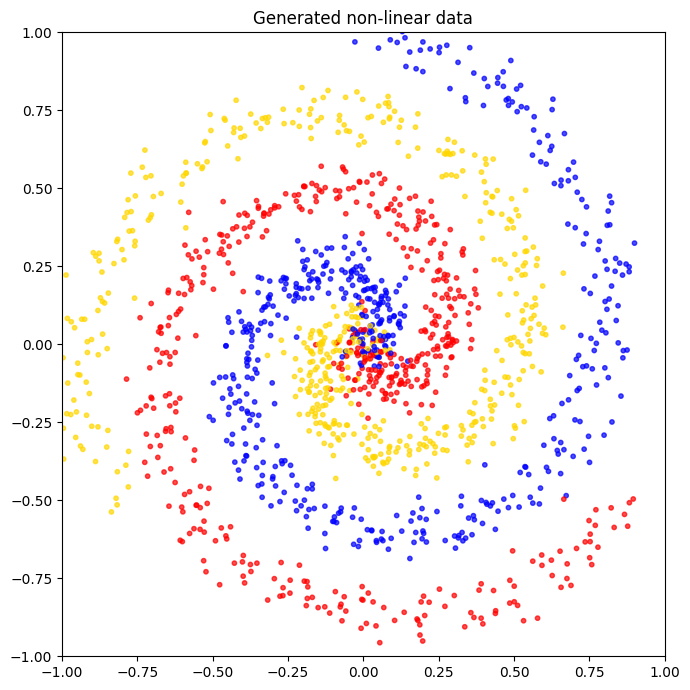

In [53]:
# Plot to verify
color_map = {"c1": "blue", "c2": "gold", "c3": "red"}
colors = df["color"].map(color_map)

plt.figure(figsize=(7, 7))
plt.scatter(df["X1"], df["X2"], c=colors, s=10, alpha=0.7)
plt.title("Generated non-linear data")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

# Save to CSV
# df.to_csv("spiral_data.csv", index=True)
# print("\nSaved to spiral_data.csv")

In [19]:
# Natrices and vextors for model training
# also Print Data shapes
X = df[["X1", "X2"]].values
y = df["color"].values
print ("X: ", np.shape(X))
print ("y: ", np.shape(y))

X:  (1500, 2)
y:  (1500,)


## Split the data

We create training and validation data sets as well as a final test set

In [16]:
import collections
from sklearn.model_selection import train_test_split

In [15]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

In [14]:
# Helper fuction to create the train validation test split
#  use two successive applications of train_test_split from sklearn.model_selection

def train_val_test_split(X, y, train_size):
    """Split dataset into data splits."""
    X_train, X_, y_train, y_ = train_test_split(X, y, train_size=TRAIN_SIZE, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_, y_, train_size=0.5, stratify=y_)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [20]:
# Create data splits
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X=X, y=y, train_size=TRAIN_SIZE)
print (f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print (f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print (f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print (f"Sample point: {X_train[0]} → {y_train[0]}")

X_train: (1050, 2), y_train: (1050,)
X_val: (225, 2), y_val: (225,)
X_test: (225, 2), y_test: (225,)
Sample point: [-0.00262302 -0.00616305] → c3


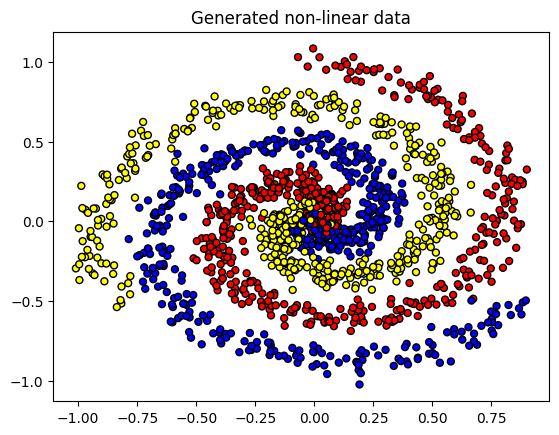

In [21]:
# Visualize data
plt.title("Generated non-linear data")
colors = {"c1": "red", "c2": "yellow", "c3": "blue"}
plt.scatter(X[:, 0], X[:, 1], c=[colors[_y] for _y in y], edgecolors="k", s=25)
plt.show()

## Label Encoding

We use a patter of fitting the label encoder on the Train data set and then use it to score all the other data sets to avoid any peeking at the validation and test sets. We have also used stratification to ensure that all the label values are equally represented in all the datasets.

In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
# Output vectorizer
#  The label encoder can be use to both encode and decode our labels 
#   we will fit it on the training labels data set
label_encoder = LabelEncoder()

In [24]:
# Fit on train data
label_encoder = label_encoder.fit(y_train)
classes = list(label_encoder.classes_)
print (f"classes: {classes}")

classes: ['c1', 'c2', 'c3']


In [25]:
# Convert labels to tokens
print (f"y_train[0]: {y_train[0]}")
y_train = label_encoder.transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)
print (f"y_train[0]: {y_train[0]}")

y_train[0]: c3
y_train[0]: 2


In [26]:
# Class weights
counts = np.bincount(y_train)
class_weights = {i: 1.0/count for i, count in enumerate(counts)}
print (f"counts: {counts}\nweights: {class_weights}")

counts: [350 350 350]
weights: {0: 0.002857142857142857, 1: 0.002857142857142857, 2: 0.002857142857142857}


## Standardize the data

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
# Standardize the data (mean=0, std=1) using training data
X_scaler = StandardScaler().fit(X_train)

In [29]:
# Apply scaler on training and test data (don't standardize outputs for classification)
X_train = X_scaler.transform(X_train)
X_val = X_scaler.transform(X_val)
X_test = X_scaler.transform(X_test)

In [30]:
# Check (means should be ~0 and std should be ~1)
print (f"X_test[0]: mean: {np.mean(X_test[:, 0], axis=0):.1f}, std: {np.std(X_test[:, 0], axis=0):.1f}")
print (f"X_test[1]: mean: {np.mean(X_test[:, 1], axis=0):.1f}, std: {np.std(X_test[:, 1], axis=0):.1f}")

X_test[0]: mean: 0.0, std: 1.0
X_test[1]: mean: -0.1, std: 1.0


## Linear Model

We are first going to build a linear model using torch to motivate the use of nonlinear activation functions.
We expect this model to perform poorly but the point is to set up a benchmmark.

In [31]:
import torch

In [32]:
# Set seed for reproducibility
torch.manual_seed(SEED)

#### Model

We create a linear model using one hidden layer of weights.
Because there is no activation fucntion between the layer this is essentially the same as a linear model, we can't learn any non-linearities

In [33]:
from torch import nn
import torch.nn.functional as F

In [37]:
INPUT_DIM = X_train.shape[1] # X is 2-dimensional
HIDDEN_DIM = 100
NUM_CLASSES = len(classes) # 3 classes

In [38]:
class LinearModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(LinearModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_in):
        z = self.fc1(x_in) # linear activation
        z = self.fc2(z)
        return z

In [39]:
# Initialize model
model = LinearModel(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES)
print (model.named_parameters)

<bound method Module.named_parameters of LinearModel(
  (fc1): Linear(in_features=2, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=3, bias=True)
)>


### Training

We go ahead and train the model we defined above

In [40]:
from torch.optim import Adam

In [41]:
LEARNING_RATE = 1e-2
NUM_EPOCHS = 10
BATCH_SIZE = 32

In [42]:
# Define Loss
class_weights_tensor = torch.Tensor(list(class_weights.values()))
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [43]:
# Accuracy
def accuracy_fn(y_pred, y_true):
    n_correct = torch.eq(y_pred, y_true).sum().item()
    accuracy = (n_correct / len(y_pred)) * 100
    return accuracy

In [44]:
# Optimizer
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

In [45]:
# Convert data to tensors
X_train = torch.Tensor(X_train)
y_train = torch.LongTensor(y_train)
X_val = torch.Tensor(X_val)
y_val = torch.LongTensor(y_val)
X_test = torch.Tensor(X_test)
y_test = torch.LongTensor(y_test)

In [46]:
# Training
for epoch in range(NUM_EPOCHS):
    # Forward pass
    y_pred = model(X_train)

    # Loss
    loss = loss_fn(y_pred, y_train)

    # Zero all gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    if epoch%1==0:
        predictions = y_pred.max(dim=1)[1] # class
        accuracy = accuracy_fn(y_pred=predictions, y_true=y_train)
        print (f"Epoch: {epoch} | loss: {loss:.2f}, accuracy: {accuracy:.1f}")

Epoch: 0 | loss: 1.19, accuracy: 32.3
Epoch: 1 | loss: 1.07, accuracy: 39.0
Epoch: 2 | loss: 1.07, accuracy: 35.7
Epoch: 3 | loss: 1.10, accuracy: 36.9
Epoch: 4 | loss: 1.11, accuracy: 36.3
Epoch: 5 | loss: 1.10, accuracy: 35.0
Epoch: 6 | loss: 1.08, accuracy: 34.6
Epoch: 7 | loss: 1.06, accuracy: 37.1
Epoch: 8 | loss: 1.06, accuracy: 37.0
Epoch: 9 | loss: 1.06, accuracy: 38.7


### Evaluation

In [47]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

In [48]:
def get_metrics(y_true, y_pred, classes):
    """Per-class performance metrics."""
    # Performance
    performance = {"overall": {}, "class": {}}

    # Overall performance
    metrics = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    performance["overall"]["precision"] = metrics[0]
    performance["overall"]["recall"] = metrics[1]
    performance["overall"]["f1"] = metrics[2]
    performance["overall"]["num_samples"] = np.float64(len(y_true))

    # Per-class performance
    metrics = precision_recall_fscore_support(y_true, y_pred, average=None)
    for i in range(len(classes)):
        performance["class"][classes[i]] = {
            "precision": metrics[0][i],
            "recall": metrics[1][i],
            "f1": metrics[2][i],
            "num_samples": np.float64(metrics[3][i]),
        }

    return performance

In [49]:
# Predictions
y_prob = F.softmax(model(X_test), dim=1)
print (f"sample probability: {y_prob[0]}")
y_pred = y_prob.max(dim=1)[1]
print (f"sample class: {y_pred[0]}")

sample probability: tensor([0.3352, 0.3013, 0.3635], grad_fn=<SelectBackward0>)
sample class: 2


In [50]:
# # Performance
performance = get_metrics(y_true=y_test, y_pred=y_pred, classes=classes)
print (json.dumps(performance, indent=2))

{
  "overall": {
    "precision": 0.36677371290015087,
    "recall": 0.36,
    "f1": 0.3480995975141174,
    "num_samples": 225.0
  },
  "class": {
    "c1": {
      "precision": 0.3404255319148936,
      "recall": 0.21333333333333335,
      "f1": 0.26229508196721313,
      "num_samples": 75.0
    },
    "c2": {
      "precision": 0.33884297520661155,
      "recall": 0.5466666666666666,
      "f1": 0.4183673469387755,
      "num_samples": 75.0
    },
    "c3": {
      "precision": 0.42105263157894735,
      "recall": 0.32,
      "f1": 0.3636363636363636,
      "num_samples": 75.0
    }
  }
}


In [51]:
def plot_multiclass_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))
    cmap = plt.cm.Spectral

    X_test = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    y_pred = F.softmax(model(X_test), dim=1)
    _, y_pred = y_pred.max(dim=1)
    y_pred = y_pred.reshape(xx.shape)
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

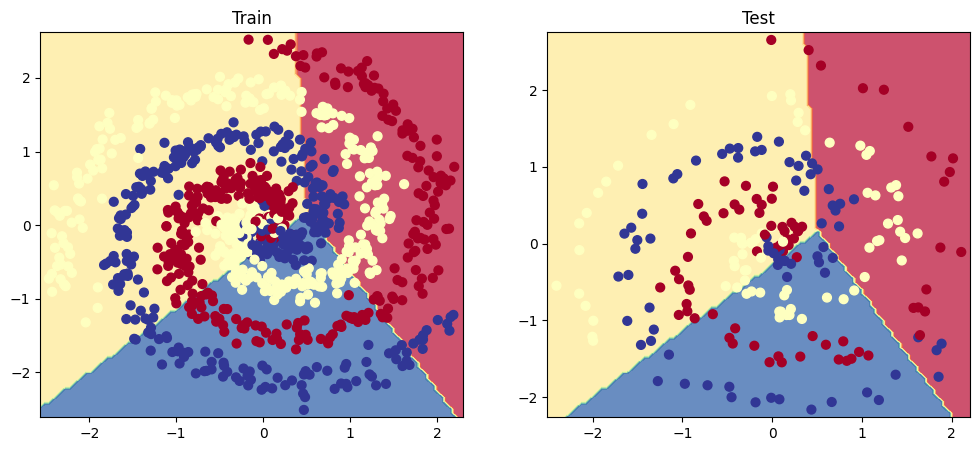

In [52]:
# Visualize the decision boundary
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_multiclass_decision_boundary(model=model, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_multiclass_decision_boundary(model=model, X=X_test, y=y_test)
plt.show()

## Taking a crack on our on at using Pytorch

As an exercise to practice working witht he pytorch library we rewrite both the model and the training loop for the two layer linear model using pytorch elements.

In [96]:
# some imports
import torch
from torch import nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.optim as optim

In [97]:
# define the dataset
dataset = TensorDataset(X_train, y_train)

In [98]:
# define the dataloader
dataloader = DataLoader(dataset, batch_size = 32, shuffle = True)

In [109]:
# define the model
model = nn.Sequential(
    nn.Linear(INPUT_DIM, HIDDEN_DIM),
    nn.Linear(HIDDEN_DIM, NUM_CLASSES)
)

In [101]:
print(f"input_dim: {INPUT_DIM}")
print(f"hidden_dim: {HIDDEN_DIM}")
print(f"num_classes: {NUM_CLASSES}")

input_dim: 2
hidden_dim: 100
num_classes: 3


In [102]:
# Define the loss function
criterion = nn.CrossEntropyLoss()

In [112]:
# define the optimizer
# optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum = 0.95)
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [104]:
# define the number of epochs
num_epoch = 25

In [113]:
for epoch in range(num_epoch):
    for data in dataloader:
        # Set the gradients to zero
        optimizer.zero_grad()
        # Get feature and target from the data loader
        feature, target = data
        # Run a forward pass
        pred = model(feature)
        # Compute loss and gradients
        loss = criterion(pred, target)
        loss.backward()
        # Update the parameters
        optimizer.step()

    if epoch%1==0:
        predictions = pred.max(dim=1)[1] # class
        accuracy = accuracy_fn(y_pred=predictions, y_true=target)
        print (f"Epoch: {epoch} | loss: {loss:.2f}, accuracy: {accuracy:.1f}")

Epoch: 0 | loss: 1.04, accuracy: 50.0
Epoch: 1 | loss: 1.10, accuracy: 26.9
Epoch: 2 | loss: 1.17, accuracy: 26.9
Epoch: 3 | loss: 1.12, accuracy: 23.1
Epoch: 4 | loss: 0.92, accuracy: 57.7
Epoch: 5 | loss: 1.22, accuracy: 11.5
Epoch: 6 | loss: 1.13, accuracy: 30.8
Epoch: 7 | loss: 1.13, accuracy: 26.9
Epoch: 8 | loss: 1.03, accuracy: 50.0
Epoch: 9 | loss: 1.20, accuracy: 26.9
Epoch: 10 | loss: 1.00, accuracy: 50.0
Epoch: 11 | loss: 1.03, accuracy: 50.0
Epoch: 12 | loss: 1.05, accuracy: 42.3
Epoch: 13 | loss: 0.97, accuracy: 53.8
Epoch: 14 | loss: 1.03, accuracy: 34.6
Epoch: 15 | loss: 0.98, accuracy: 46.2
Epoch: 16 | loss: 1.11, accuracy: 30.8
Epoch: 17 | loss: 0.99, accuracy: 53.8
Epoch: 18 | loss: 1.02, accuracy: 53.8
Epoch: 19 | loss: 1.01, accuracy: 38.5
Epoch: 20 | loss: 1.15, accuracy: 30.8
Epoch: 21 | loss: 1.11, accuracy: 34.6
Epoch: 22 | loss: 1.13, accuracy: 30.8
Epoch: 23 | loss: 1.01, accuracy: 38.5
Epoch: 24 | loss: 1.03, accuracy: 46.2


In [114]:
# Predictions
y_prob = F.softmax(model(X_test), dim=1)
print (f"sample probability: {y_prob[0]}")
y_pred = y_prob.max(dim=1)[1]
print (f"sample class: {y_pred[0]}")

sample probability: tensor([0.3852, 0.2476, 0.3671], grad_fn=<SelectBackward0>)
sample class: 0


In [115]:
# # Performance
performance = get_metrics(y_true=y_test, y_pred=y_pred, classes=classes)
print (json.dumps(performance, indent=2))

{
  "overall": {
    "precision": 0.35592185592185593,
    "recall": 0.35555555555555557,
    "f1": 0.3522995840068351,
    "num_samples": 225.0
  },
  "class": {
    "c1": {
      "precision": 0.358974358974359,
      "recall": 0.37333333333333335,
      "f1": 0.36601307189542487,
      "num_samples": 75.0
    },
    "c2": {
      "precision": 0.35714285714285715,
      "recall": 0.26666666666666666,
      "f1": 0.30534351145038163,
      "num_samples": 75.0
    },
    "c3": {
      "precision": 0.3516483516483517,
      "recall": 0.4266666666666667,
      "f1": 0.3855421686746988,
      "num_samples": 75.0
    }
  }
}


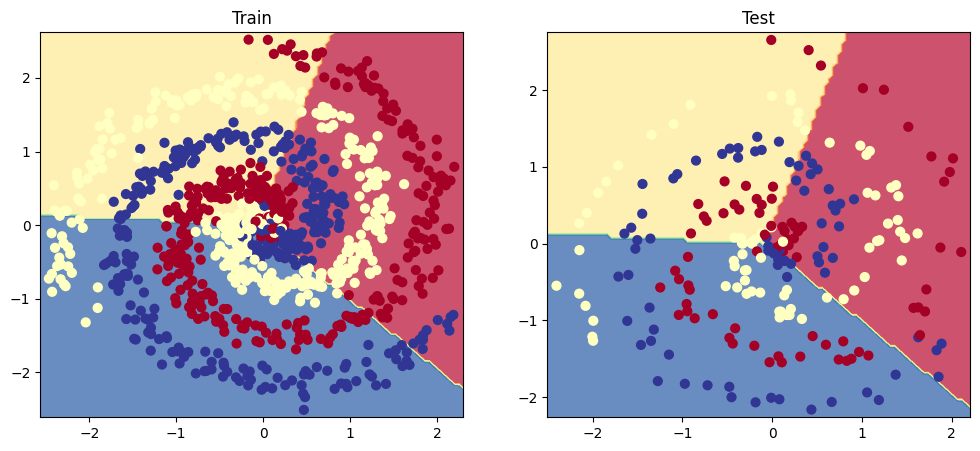

In [116]:
# Visualize the decision boundary
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_multiclass_decision_boundary(model=model, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_multiclass_decision_boundary(model=model, X=X_test, y=y_test)
plt.show()

## Now let's use an activation function to fit non-linear decision boundaries

We revert to the code we use at the beginning but define a new class MLP inheriting from nn.Module 

We are only adding a change to one line of code "z = F.relu(self.fc1(x_in))" we are wrapping the first linear layer with a ReLU activation function; this is enough to generate nonlinear boundaries that can fit the training data very effectivcely.

### Model

In [123]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_in):
        z = F.relu(self.fc1(x_in)) # ReLU activation function added!
        z = self.fc2(z)
        return z

In [124]:
# Initialize model
model = MLP(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES)
print (model.named_parameters)

<bound method Module.named_parameters of MLP(
  (fc1): Linear(in_features=2, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=3, bias=True)
)>


### Training

In [125]:
# Define Loss
class_weights_tensor = torch.Tensor(list(class_weights.values()))
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [126]:
# Accuracy
def accuracy_fn(y_pred, y_true):
    n_correct = torch.eq(y_pred, y_true).sum().item()
    accuracy = (n_correct / len(y_pred)) * 100
    return accuracy

In [127]:
# Optimizer
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

In [128]:
# Convert data to tensors
X_train = torch.Tensor(X_train)
y_train = torch.LongTensor(y_train)
X_val = torch.Tensor(X_val)
y_val = torch.LongTensor(y_val)
X_test = torch.Tensor(X_test)
y_test = torch.LongTensor(y_test)

In [129]:
# Training
for epoch in range(NUM_EPOCHS*10):
    # Forward pass
    y_pred = model(X_train)

    # Loss
    loss = loss_fn(y_pred, y_train)

    # Zero all gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    if epoch%10==0:
        predictions = y_pred.max(dim=1)[1] # class
        accuracy = accuracy_fn(y_pred=predictions, y_true=y_train)
        print (f"Epoch: {epoch} | loss: {loss:.2f}, accuracy: {accuracy:.1f}")

Epoch: 0 | loss: 1.12, accuracy: 34.8
Epoch: 10 | loss: 1.00, accuracy: 36.5
Epoch: 20 | loss: 0.93, accuracy: 42.6
Epoch: 30 | loss: 0.86, accuracy: 54.9
Epoch: 40 | loss: 0.80, accuracy: 61.9
Epoch: 50 | loss: 0.74, accuracy: 67.0
Epoch: 60 | loss: 0.68, accuracy: 71.7
Epoch: 70 | loss: 0.63, accuracy: 75.7
Epoch: 80 | loss: 0.58, accuracy: 78.5
Epoch: 90 | loss: 0.53, accuracy: 80.6


### Evaluation

In [130]:
# Predictions
y_prob = F.softmax(model(X_test), dim=1)
y_pred = y_prob.max(dim=1)[1]

In [131]:
# # Performance
performance = get_metrics(y_true=y_test, y_pred=y_pred, classes=classes)
print (json.dumps(performance, indent=2))

{
  "overall": {
    "precision": 0.789580858645851,
    "recall": 0.7866666666666666,
    "f1": 0.7870643315415294,
    "num_samples": 225.0
  },
  "class": {
    "c1": {
      "precision": 0.8169014084507042,
      "recall": 0.7733333333333333,
      "f1": 0.7945205479452055,
      "num_samples": 75.0
    },
    "c2": {
      "precision": 0.8169014084507042,
      "recall": 0.7733333333333333,
      "f1": 0.7945205479452055,
      "num_samples": 75.0
    },
    "c3": {
      "precision": 0.7349397590361446,
      "recall": 0.8133333333333334,
      "f1": 0.7721518987341773,
      "num_samples": 75.0
    }
  }
}


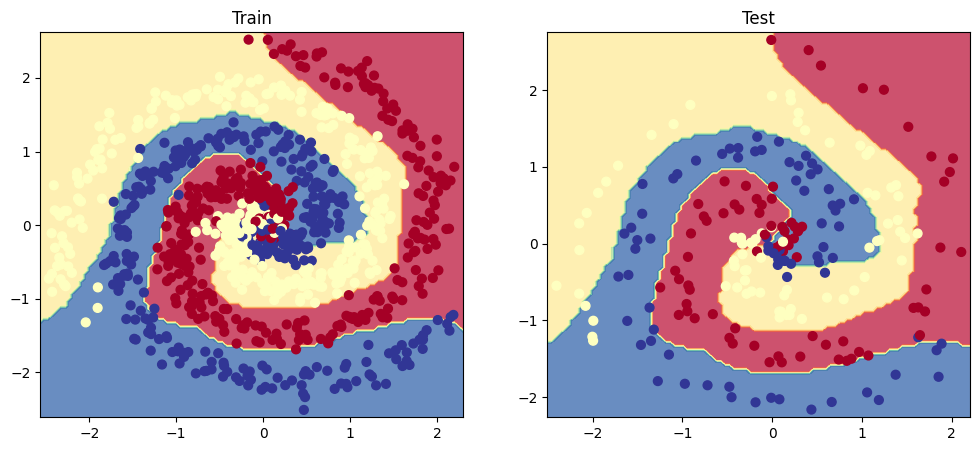

In [132]:
# Visualize the decision boundary
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_multiclass_decision_boundary(model=model, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_multiclass_decision_boundary(model=model, X=X_test, y=y_test)
plt.show()